In [93]:
import typing as T
from typing import Dict, List, Tuple
import pickle
import json
import os
import pathlib
import pathlib as P
from pathlib import Path
import sys
import pandas as pd
import itertools as it
import functools as ft
import operator as opr
import collections as clt
import math
from math import pi
import re

In [2]:
prj_root = P.Path("__file__").absolute().parent.parent.parent
if (p := str(prj_root)) not in sys.path:
  sys.path.append(p)

In [3]:
import util.metrics as um
import sklearn.metrics as metrics
import notebooks.case_analysis.embedding_analysis as ea

In [92]:
import torch as th
import numpy as np
import scipy as sci
import scipy.stats as stats
import scipy.sparse as sp
import networkx as nx
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import scipy.stats as ss
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.cm as cm
from tqdm import tqdm
import umap
import openTSNE as S
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import goatools as gt
from goatools.base import get_godag
from goatools.gosubdag.gosubdag import GoSubDag
from goatools.gosubdag.plot.gosubdag_plot import GoSubDagPlot
import graphviz

In [5]:
ns = ['cc', 'mf', 'bp']
ontology_lst = ["cellular_component",
                "molecular_function",
                "biological_process"]

In [6]:
# load go ic
# load position with count
goic_dir = prj_root / "data" / "data-netgo"
count_path = goic_dir / "term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(count_path)

In [7]:
term_count_ic = term_count_ic.astype({
    "gos": str,
    "counts": int,
    "ic": float,
    "position": str,
    "maxdep": int,
    "lgst": int,
})

In [8]:
data_path = [f"/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/{x}_data.pkl"
             for x in ["train", "valid", "test"]]
prot_data = pd.concat([pd.read_pickle(x) for x in data_path], ignore_index=True)

In [9]:
prot_labels = []
for n in ns:
    y_label = prj_root / "data" / n / "label.pkl"
    with open(y_label, "rb") as f:
        labels = pickle.load(f)
    tmp = clt.defaultdict(list)
    for k, v in zip(labels["protein"], labels["go"]):
        tmp[k].append(v)
    prot_labels.append(tmp)

In [10]:
len(prot_labels[2])

91443

In [11]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)
namespace_terms = dict(zip(ontology_lst, curr_labels))

In [12]:
# get protein name id
name_path = prj_root / "data" / "protein_name.txt"
with open(name_path, "r") as f:
    prot_lst = f.read().splitlines()# load prot names

In [13]:
# convert protein idx and label idx to protein name and go term respectively
for i, n in enumerate(ontology_lst):
    prot_labels[i] = {
        prot_lst[k]: [namespace_terms[n][x] for x in v]
        for k, v in prot_labels[i].items()
    }

In [14]:
# load performance dataframe
perf_path = prj_root / "data" / "prediction" / "hgat_performance_2.pkl"
perf_df = pd.read_pickle(perf_path)

In [15]:
# load predictions
preddata_path =  [prj_root / "data" / "prediction" / f"hgat_predictions_{x}_bi.pt"
                  for x in ["train", "valid", "test"]]

In [16]:
preddata_bi = [th.load(p) for p in preddata_path]

In [17]:
# drop annotations is None
indices = perf_df["annotations"].apply(lambda x: x is None)
perf_subdf = perf_df[~indices].reset_index(drop=True)

In [18]:
perf_subdf

,split,ontology,proteins,fmax,auprc,annotations
0,train,cc,Q6R327,0.476190,0.610485,"[GO:0031932, GO:0140535, GO:0032991, GO:000562..."
1,train,cc,A0A1D8PEJ5,0.461538,0.833333,"[GO:0005575, GO:0016020, GO:0110165]"
2,train,cc,A6NIX2,0.521739,0.620365,"[GO:0036464, GO:0000932, GO:0005622, GO:004322..."
3,train,cc,A0A1D5PZ68,0.666667,0.526786,"[GO:0005576, GO:0110165, GO:0005575, GO:0005615]"
4,train,cc,A0A0A0MTS5,0.352941,0.664716,"[GO:0012505, GO:0071944, GO:0043229, GO:011016..."
...,...,...,...,...,...,...
238470,test,bp,Q9VT33,0.160000,0.120250,"[GO:0007610, GO:0050896, GO:0042048, GO:000763..."
238471,test,bp,Q9VYA0,0.120000,0.110857,"[GO:0048519, GO:0023052, GO:0099177, GO:000726..."
238472,test,bp,Q9W5X1,0.298507,0.327778,"[GO:0023052, GO:0009966, GO:0010647, GO:004858..."
238473,test,bp,Q9Y320,0.153846,0.142901,"[GO:0007417, GO:0007399, GO:0007275, GO:000742..."


In [19]:
# load embedding
ns = ["cc", "mf", "bp"]
ontology_lst = ["cellular_component", "molecular_function", "biological_process"]
dr_root = prj_root / "data" / "derived_feature"

method_emb = []
method_goemb = []
split_type = ["train", "valid", "test"]

# prot_emb = th.load(dr_root / f"{m}_features.pt")
# go_emb = th.load(dr_root / f"{m}_go_emb.pt")
# for x in ontology_lst:
#     method_emb[x].append(prot_emb[x])
#     method_goemb[x].append(go_emb[x])
protemb_lst = [th.load(dr_root / f"hgat_features_{x}.pt")
               for x in split_type]
# go_emb = th.load(dr_root / f"hgat_go_emb.pt")

# merge the prot emb from train and test
memd_lst = [dict(it.chain.from_iterable(x.items() for x in tp))
            for tp in zip(*protemb_lst)]

# merget the prot emb of all ontologies
# firstly calculate the count of each protein
# the final embedding is the average of the embeddings
counter = clt.Counter(it.chain.from_iterable(x.keys() for x in memd_lst))
h_size = next(iter(memd_lst[0].values())).shape[0]
protemb_dict = clt.defaultdict(lambda: th.zeros(h_size, dtype=th.float32))
for embdict in memd_lst:
    for k, v in embdict.items():
        protemb_dict[k] += v
# for k in protemb_dict:
#     protemb_dict[k] /= counter[k]
print(len(protemb_dict))
# goemb_dict = dict(it.chain.from_iterable(x.items() for x in go_emb.values()))
# method_emb.append(protemb_dict)
# method_goemb.append(goemb_dict)

123534


In [20]:
# load esm embeddings
esm_path = prj_root / "data" / "features.npz"
prot_esm = np.load(esm_path)
prot_esm = {x: e for x, e in zip(prot_lst, prot_esm["features"])}

In [21]:
prot_esm = {x: e for x in protemb_dict.keys()
            if (e := prot_esm.get(x)) is not None}

In [22]:
len(prot_esm)

123534

In [23]:
selected_cases = ea.comprehensive_case_selection_scalable(perf_subdf, prot_esm, protemb_dict,
                                                          max_sample_size=50000)

Starting scalable case selection...
Sampling 50000 proteins from 238475 total proteins...
Selecting performance-based cases...
Finding functional groups...
Processing cc ontology...
Found 20 groups for cc
Processing bp ontology...
Found 20 groups for bp
Processing mf ontology...
Found 20 groups for mf
Finding clustering-based groups...
Clustering cc ontology...
Found 20 quality clusters for cc
Clustering bp ontology...
Found 20 quality clusters for bp
Clustering mf ontology...
Found 20 quality clusters for mf
Analyzing embedding changes...
Preparing embedding dimension alignment...
ESM embeddings shape: (10000, 1280)
Model embeddings shape: (10000, 128)
Applying PCA to reduce ESM embeddings from 1280 to 128 dimensions...
PCA explained variance ratio (first 10 components): [0.09255019 0.05309023 0.03905372 0.0310867  0.0257768  0.02074689
 0.01938636 0.01760105 0.01637474 0.01520235]
Total explained variance: 0.7552
Reduced ESM embeddings shape: (10000, 128)
Processing cc ontology...
  

In [24]:
selected_cases.keys()

dict_keys(['performance_based', 'functional_groups', 'clustering_groups', 'embedding_changes'])

In [25]:
# perf_selected = {}

In [26]:
selected_cases["embedding_changes"]["cc"].keys()

dict_keys(['largest_cosine_distance', 'smallest_cosine_distance', 'largest_l2_distance', 'smallest_l2_distance', 'highest_correlation', 'lowest_correlation', 'all_changes'])

In [27]:
tmp_df = []
for i, n in enumerate(ns):
    sub = selected_cases["embedding_changes"][n]["all_changes"]
    s = len(sub)
    sub_df = pd.DataFrame(sub)
    sub_df["ontology"] = n
    tmp_df.append(sub_df)

changed_df = pd.concat(tmp_df)

In [28]:
changed_df = changed_df.rename(columns={"protein":"proteins"})

In [29]:
anno_counter = clt.Counter(it.chain.from_iterable(changed_df["annotations"]))

In [30]:
# removet the root annotation
BIOLOGICAL_PROCESS = 'GO:0008150'
MOLECULAR_FUNCTION = 'GO:0003674'
CELLULAR_COMPONENT = 'GO:0005575'
anno_counter.pop(BIOLOGICAL_PROCESS)
anno_counter.pop(MOLECULAR_FUNCTION)
anno_counter.pop(CELLULAR_COMPONENT)

3423

In [31]:
fng_df = []
for i, n in enumerate(ns):
    tmp_df = []
    for i, ds in enumerate(selected_cases["functional_groups"][n]):
        df = pd.DataFrame(ds)
        df["functional_group"] = f"{n}_{i}"
        tmp_df.append(df)
        
    sub_df = pd.concat(tmp_df)
    sub_df["ontology"] = n
    fng_df.append(sub_df)

func_group_df = pd.concat(fng_df)

In [32]:
clu_df = []
for i, n in enumerate(ns):
    tmp_df = []
    for i, ds in enumerate(selected_cases["clustering_groups"][n]):
        df = pd.DataFrame(ds)
        df["clustering_group"] = f"{n}_{i}"
        tmp_df.append(df)
    
    sub_df = pd.concat(tmp_df)
    sub_df["ontology"] = n
    clu_df.append(sub_df)

clu_group_df = pd.concat(clu_df).reset_index(drop=True)

In [33]:
clu_group_df = clu_group_df.rename(columns={"protein": "proteins"})

In [34]:
clu_group_df

,proteins,fmax,auprc,annotations,clustering_group,ontology
0,P41808,0.300000,0.833333,"[GO:0005622, GO:0005575, GO:0110165]",cc_0,cc
1,Q9NXZ2,0.428571,0.666667,"[GO:0005622, GO:0005575, GO:0110165]",cc_0,cc
2,Q5BBS5,0.545455,0.666667,"[GO:0005622, GO:0005575, GO:0110165]",cc_0,cc
3,Q9H2E6,0.500000,0.634259,"[GO:0005622, GO:0005575, GO:0110165]",cc_0,cc
4,Q4WDM0,0.461538,0.833333,"[GO:0005575, GO:0005622, GO:0110165]",cc_0,cc
...,...,...,...,...,...,...
18416,Q9JLB9,0.343750,0.327552,"[GO:0098609, GO:0045184, GO:1902414, GO:000956...",bp_19,bp
18417,Q8MLN9,0.474576,0.496192,"[GO:0022008, GO:0042052, GO:0001751, GO:003018...",bp_19,bp
18418,Q9NGV2,0.471910,0.549403,"[GO:0022008, GO:0042052, GO:0001751, GO:003018...",bp_19,bp
18419,Q05AK0,0.250000,0.187404,"[GO:0072359, GO:0048731, GO:0048513, GO:004804...",bp_19,bp


In [35]:
col_names = ["proteins", "clustering_group"]

In [36]:
chng_clu_df = changed_df.merge(clu_group_df[col_names], on="proteins", how="left")

In [37]:
chng_clu_df = chng_clu_df[~chng_clu_df["clustering_group"].isna()]

In [38]:
group_counter = clt.Counter(chng_clu_df["clustering_group"])

In [39]:
# load structure plddt data
plddt_path = prj_root / "data" / "protein_plddt_avgRes.csv"
plddt_df = pd.read_csv(plddt_path)

In [40]:
plddt_df = plddt_df.rename(columns={"Protein": "proteins",
                            "Avg_pLDDT": "pLDDT"})

In [41]:
clu_group_df = clu_group_df.merge(plddt_df, on="proteins", how="inner")

In [42]:
def get_predicted_annotations(pred_data,
                              curr_labels, 
                              by, 
                              name):
    assert isinstance(by, int)
    for pred in pred_data:
        pred_result = None
        assert by < len(pred)
        p = pred[by]
        assert p is not None
        if (tmp := p.get(name)) is not None:
            pred_result = tmp.detach().cpu().numpy()
            break
    targs, preds = pred_result
    assert by < len(curr_labels)
    label_lst = curr_labels[by]
    tp = preds * targs 
    indices = np.where(tp)[0]
    return [label_lst[i] for i in indices]

In [56]:
gname = "bp_6"
# pname = "Q93ZL5"
# pname = "Q9QZQ0"
clu_group_df[clu_group_df["clustering_group"] == gname].nlargest(50, "fmax").nsmallest(20, "pLDDT")
# clu_group_df[clu_group_df["proteins"] == pname]

,proteins,fmax,auprc,annotations,clustering_group,ontology,pLDDT
15688,Q16247,0.941176,0.997280,"[GO:0006139, GO:0034641, GO:0006355, GO:006025...",bp_6,bp,40.16
15568,Q9FZE3,0.989691,0.999787,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,50.79
15572,F4KEI6,0.941176,0.997868,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,51.91
15527,Q9LF34,0.933333,0.995159,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,52.42
15457,Q9CAA9,0.950495,0.989583,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,53.19
15850,Q69JI7,0.932039,0.989583,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,53.66
15356,Q8RWX7,0.929825,0.942629,"[GO:0006139, GO:0034641, GO:0006355, GO:000835...",bp_6,bp,54.26
15323,Q93ZL5,0.941176,0.997685,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,54.70
15718,Q8GZV6,0.960000,0.989583,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,54.72
15817,Q03414,0.939597,0.968828,"[GO:0006139, GO:0034641, GO:0009893, GO:000989...",bp_6,bp,56.34


In [44]:
def create_protein_network(clu_group_df, group_name, protein_features, 
                          similarity_threshold=0.5, 
                          top_n=50
                          ):
    """
    Create a network visualization for proteins in a specific clustering group
    
    Parameters:
    - clu_group_df: DataFrame with clustering information
    - group_name: Name of the clustering group (e.g., "bp_4")
    - protein_features: Dictionary or DataFrame with protein features/embeddings
    - similarity_threshold: Minimum similarity score to create an edge
    - top_n: Number of proteins to visualize
    """
    
    # 1. Select proteins from the clustering group
    group_proteins = clu_group_df[clu_group_df["clustering_group"] == group_name]\
                    .nlargest(top_n*2, "fmax").nsmallest(top_n, "pLDDT")
    
    print(f"Selected {len(group_proteins)} proteins from {group_name}")
    print(f"pLDDT range: {group_proteins['pLDDT'].min():.2f} - {group_proteins['pLDDT'].max():.2f}")
    
    # 2. Extract features for these proteins
    # Assuming you have a function or dictionary to get features
    protein_list = group_proteins['proteins'].tolist()
    
    # Example: If features are in a dictionary
    features_matrix = []
    valid_proteins = []
    
    for protein in protein_list:
        if protein in protein_features:
            features_matrix.append(protein_features[protein])
            valid_proteins.append(protein)
    
    features_matrix = np.array(features_matrix)
    
    # 3. Calculate pairwise similarities
    similarity_matrix = cosine_similarity(features_matrix)
    
    # 4. Create network graph
    G = nx.Graph()
    
    # Add nodes with attributes
    for idx, protein in enumerate(valid_proteins):
        protein_data = group_proteins[group_proteins['proteins'] == protein].iloc[0]
        G.add_node(protein, 
                   pLDDT=protein_data['pLDDT'],
                   fmax=protein_data['fmax'],
                   auprc=protein_data['auprc'])
    
    # Add edges based on similarity
    for i in range(len(valid_proteins)):
        for j in range(i + 1, len(valid_proteins)):
            similarity = similarity_matrix[i, j]
            if similarity >= similarity_threshold:
                G.add_edge(valid_proteins[i], valid_proteins[j], 
                          weight=similarity)
    
    print(f"Network has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    return G, group_proteins

def visualize_protein_network(G, group_proteins, group_name, figsize=(12, 12)):
    """
    Visualize the protein network with pLDDT-based coloring
    """
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig, ax1 = plt.subplots(1, 1, figsize=figsize)
    
    # Layout algorithms
    pos = nx.spring_layout(G, 
                        #    k=1.5, 
                           iterations=50, seed=42)
    # pos = nx.kamada_kawai_layout(G)
    
    # Get node attributes
    plddt_values = [G.nodes[node]['pLDDT'] for node in G.nodes()]
    fmax_values = [G.nodes[node]['fmax'] for node in G.nodes()]
    
    # Color map for pLDDT
    norm = plt.Normalize(vmin=min(plddt_values), vmax=max(plddt_values))
    cmap = cm.get_cmap('RdYlBu_r')  # Red for low, Blue for high pLDDT
    
    # Plot 1: Network colored by pLDDT
    # ax1.set_title(f'{group_name} Protein Network - Colored by pLDDT', fontsize=16)
    
    # Draw edges
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.3, 
                          width=[w*3 for w in weights],
                          edge_color='gray')
    
    # Draw nodes
    node_colors = [cmap(norm(plddt)) for plddt in plddt_values]
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax1,
                                   node_color=plddt_values,
                                   node_size=500,
                                   cmap='RdYlBu_r',
                                   vmin=min(plddt_values),
                                   vmax=max(plddt_values))
    
    # Add labels
    nx.draw_networkx_labels(G, pos, ax=ax1, font_size=8)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1, label='pLDDT Score')
    
    # # Plot 2: Degree distribution and pLDDT relationship
    # ax2.set_title('Node Connectivity vs pLDDT', fontsize=16)
    
    # degrees = [G.degree(node) for node in G.nodes()]
    # ax2.scatter(plddt_values, degrees, c=fmax_values, 
    #             cmap='viridis', s=100, alpha=0.7)
    # ax2.set_xlabel('pLDDT Score')
    # ax2.set_ylabel('Node Degree (Number of Connections)')
    
    # # Add colorbar for fmax
    # sm2 = plt.cm.ScalarMappable(cmap='viridis', 
    #                             norm=plt.Normalize(vmin=min(fmax_values), 
    #                                               vmax=max(fmax_values)))
    # sm2.set_array([])
    # cbar2 = plt.colorbar(sm2, ax=ax2, label='F-max Score')
    
    # # Add annotation
    # ax2.text(0.05, 0.95, f'Correlation: {np.corrcoef(plddt_values, degrees)[0,1]:.3f}',
    #          transform=ax2.transAxes, fontsize=12,
    #          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig

def analyze_network_properties(G, group_proteins):
    """
    Analyze and print network properties
    """
    print("\n=== Network Analysis ===")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Network density: {nx.density(G):.3f}")
    
    # Get connected components
    components = list(nx.connected_components(G))
    print(f"Number of connected components: {len(components)}")
    
    # Analyze correlation between pLDDT and connectivity
    plddt_values = [G.nodes[node]['pLDDT'] for node in G.nodes()]
    degrees = [G.degree(node) for node in G.nodes()]
    correlation = np.corrcoef(plddt_values, degrees)[0, 1]
    
    print(f"\nCorrelation between pLDDT and node degree: {correlation:.3f}")
    
    # Find hub proteins (highly connected)
    degree_dict = dict(G.degree())
    top_hubs = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    
    print("\nTop 10 hub proteins:")
    for protein, degree in top_hubs:
        plddt = G.nodes[protein]['pLDDT']
        fmax = G.nodes[protein]['fmax']
        print(f"  {protein}: degree={degree}, pLDDT={plddt:.2f}, fmax={fmax:.3f}")

def create_feature_heatmap(protein_features, protein_list, group_proteins):
    """
    Create a heatmap showing feature similarities
    """
    # Extract features for proteins
    features_matrix = []
    valid_proteins = []
    
    for protein in protein_list:
        if protein in protein_features:
            features_matrix.append(protein_features[protein])
            valid_proteins.append(protein)
    
    features_matrix = np.array(features_matrix)
    similarity_matrix = cosine_similarity(features_matrix)
    
    # Create DataFrame for heatmap
    sim_df = pd.DataFrame(similarity_matrix, 
                         index=valid_proteins, 
                         columns=valid_proteins)
    
    # Get pLDDT values for annotation
    plddt_dict = dict(zip(group_proteins['proteins'], group_proteins['pLDDT']))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Create heatmap
    sns.heatmap(sim_df, cmap='RdBu_r', center=0.5, 
                square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Cosine Similarity"})
    
    # Add pLDDT annotations on the side
    for idx, protein in enumerate(valid_proteins):
        plddt = plddt_dict.get(protein, 0)
        color = 'red' if plddt < 60 else 'green'
        ax.text(len(valid_proteins) + 0.5, idx + 0.5, 
                f'{plddt:.1f}', ha='left', va='center',
                color=color, fontsize=8)
    
    # ax.set_title(f'Feature Similarity Matrix - {group_name}', fontsize=16)
    ax.text(len(valid_proteins) + 0.5, -1, 'pLDDT', 
            ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    return fig


In [57]:
# load embedding
ns = ["cc", "mf", "bp"]
ontology_lst = ["cellular_component", "molecular_function", "biological_process"]
dr_root = prj_root / "data" / "derived_feature"
method_names = ["ProGO-PFL", 
                ]
method_labelname = ["hgat", 
                    ]
method_emb = []
method_goemb = []
split_type = ["train", "valid", "test"]
for m in method_labelname:
    protemb_lst = [th.load(dr_root / f"{m}_features_{x}.pt")
                   for x in split_type]
    
    # merge the prot emb from train and test
    memd_lst = [dict(it.chain.from_iterable(x.items() for x in tp))
                for tp in zip(*protemb_lst)]
    
    # merget the prot emb of all ontologies
    # firstly calculate the count of each protein
    # the final embedding is the average of the embeddings
    counter = clt.Counter(it.chain.from_iterable(x.keys() for x in memd_lst))
    h_size = next(iter(memd_lst[0].values())).shape[0]
    protemb_dict = clt.defaultdict(lambda: th.zeros(h_size, dtype=th.float32))
    for embdict in memd_lst:
        for k, v in embdict.items():
            protemb_dict[k] += v
    
    print(len(protemb_dict))

123534


In [64]:
group_name = "bp_6"
top_n = 20
protein_list = clu_group_df[clu_group_df["clustering_group"] == group_name]\
                  .nlargest(top_n*2, "fmax").nsmallest(top_n, "pLDDT")['proteins'].tolist()

In [65]:
protein_features = {x: e for x in protein_list
                    if (e := protemb_dict.get(x)) is not None}

In [66]:
G, group_proteins = create_protein_network(clu_group_df, group_name, 
                                             protein_features, 
                                             top_n=top_n,
                                            #  similarity_threshold=0.1
                                             )

Selected 20 proteins from bp_6
pLDDT range: 40.16 - 66.06
Network has 20 nodes and 189 edges


In [67]:
edge_lst = G.edges.data("weight")

In [68]:
edge_df = pd.DataFrame([{"Source": p1, "Target": p2, "Weight": p3}
                        for p1, p2, p3 in edge_lst])

In [69]:
# # save edge list
# save_dir = prj_root / "notebooks" / "case_analysis" / "edge"
# save_path = save_dir / "edge_list.csv"
# edge_df.to_csv(save_path, sep="\t", index=False)

/tmp/ipykernel_2087395/1986982831.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r')  # Red for low, Blue for high pLDDT


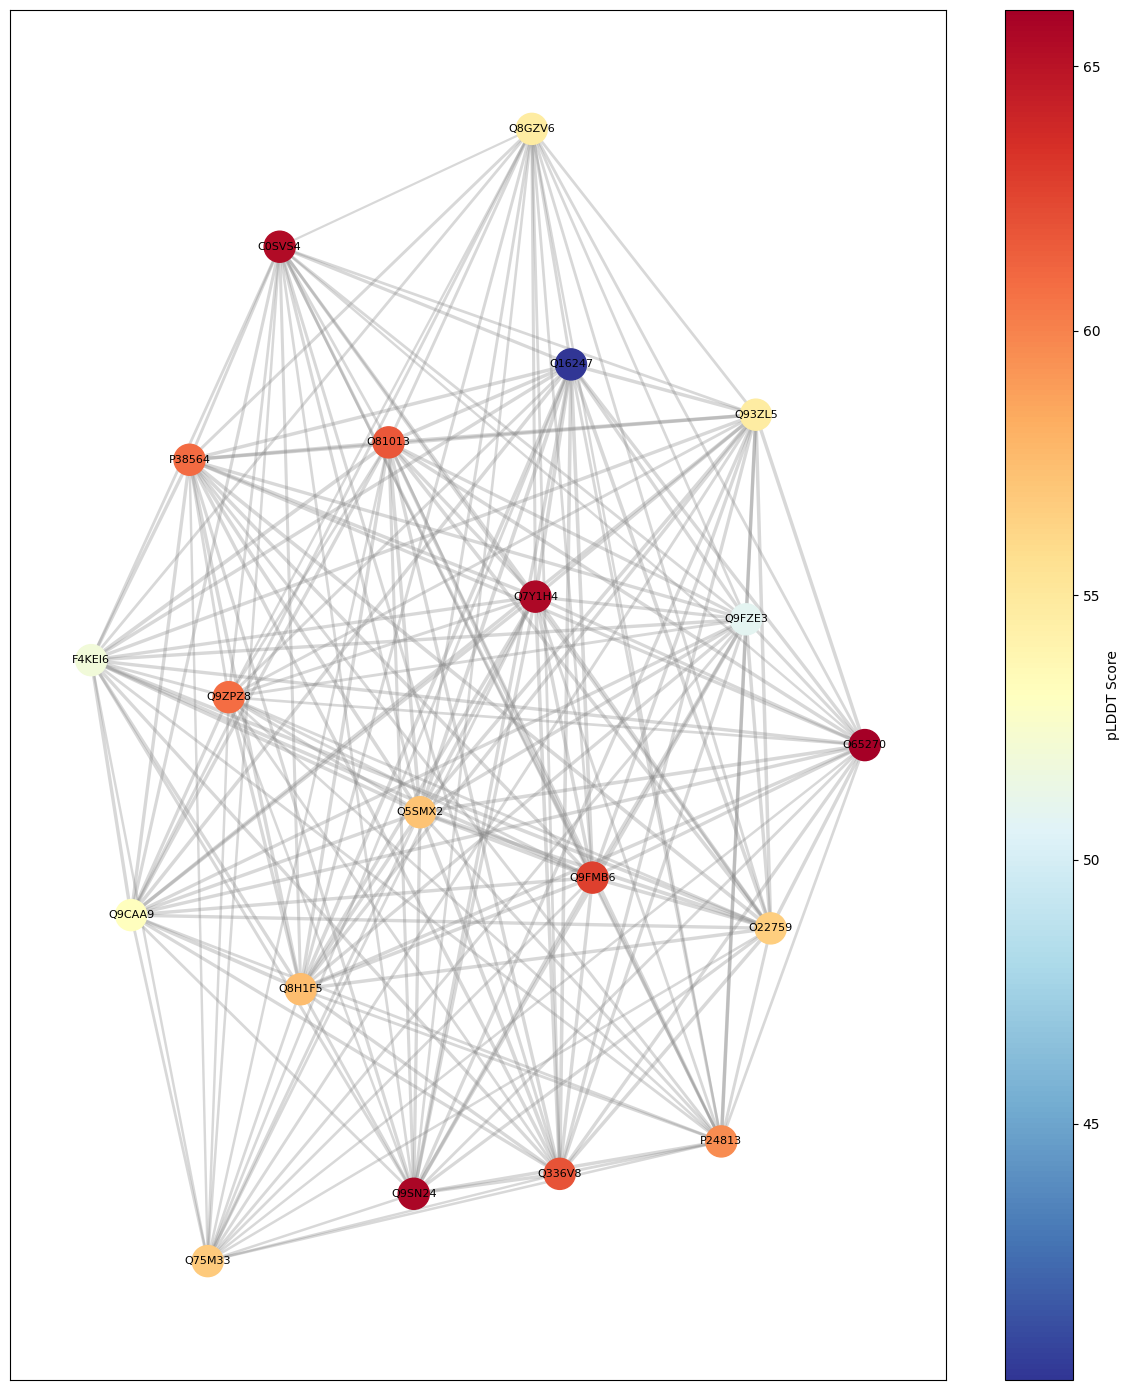

In [70]:
fig1 = visualize_protein_network(G, group_proteins, group_name,
                                 figsize=(12,14))

In [71]:
# save figure
save_dir = prj_root / "notebooks" / "case_analysis" / "edge"
save_path = save_dir / f"{group_name}_cos_sim_graph.png"
fig1.savefig(save_path, dpi=300, bbox_inches="tight")
save_path = save_dir / f"{group_name}_cos_sim_graph.svg"
fig1.savefig(save_path, bbox_inches="tight")

In [74]:
name_lst = ["Q93ZL5",
            "Q16247",
            "Q9FZE3",
            "O65270",
            "F4KEI6",
            "Q9CAA9",
            "Q75M33",
            "Q9SN24",
            ]
clu_group_df[clu_group_df["proteins"].isin(name_lst)]

,proteins,fmax,auprc,annotations,clustering_group,ontology,pLDDT
1380,Q75M33,1.000000,0.937500,"[GO:0005634, GO:0043231, GO:0043227, GO:000562...",cc_2,cc,56.78
15232,Q9SN24,0.950495,0.992392,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,65.71
15323,Q93ZL5,0.941176,0.997685,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,54.70
15457,Q9CAA9,0.950495,0.989583,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,53.19
15568,Q9FZE3,0.989691,0.999787,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,50.79
15572,F4KEI6,0.941176,0.997868,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,51.91
15677,O65270,0.967742,0.998750,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,66.06
15688,Q16247,0.941176,0.997280,"[GO:0006139, GO:0034641, GO:0006355, GO:006025...",bp_6,bp,40.16
15762,Q75M33,0.960000,0.979167,"[GO:0006139, GO:0051171, GO:0006725, GO:003464...",bp_6,bp,56.78


In [75]:
anno_lst = [get_predicted_annotations(preddata_bi, curr_labels,by=2,name=x)
            for x in name_lst]

In [76]:
inter_anno = ft.reduce(lambda r,e: r.intersection(e), anno_lst, set(anno_lst[0]))

In [77]:
term_count_ic[term_count_ic["gos"].isin(inter_anno)]

,gos,counts,ic,position,maxdep,lgst
9855,GO:0060255,18238,2.325925,Shallow,16,5
9880,GO:0044238,37769,1.275670,Medium,8,3
10511,GO:0044249,20890,2.130060,Medium,12,4
10593,GO:0043170,32928,1.473558,Shallow,20,4
11845,GO:0080090,16198,2.497057,Shallow,20,5
12220,GO:2000112,11156,3.035053,Medium,17,7
12309,GO:0009987,75687,0.272827,Shallow,19,2
12743,GO:2001141,9838,3.216436,Medium,17,9
12895,GO:0019219,11239,3.024359,Medium,17,6
13511,GO:1901360,21324,2.100395,Shallow,14,4


In [69]:
analyze_network_properties(G, group_proteins)


=== Network Analysis ===
Number of nodes: 20
Number of edges: 189
Network density: 0.995
Number of connected components: 1

Correlation between pLDDT and node degree: 0.134

Top 10 hub proteins:
  Q16247: degree=19, pLDDT=40.16, fmax=0.941
  Q9FZE3: degree=19, pLDDT=50.79, fmax=0.990
  F4KEI6: degree=19, pLDDT=51.91, fmax=0.941
  Q9CAA9: degree=19, pLDDT=53.19, fmax=0.950
  Q93ZL5: degree=19, pLDDT=54.70, fmax=0.941
  O22759: degree=19, pLDDT=56.65, fmax=0.950
  Q5SMX2: degree=19, pLDDT=57.24, fmax=0.941
  Q8H1F5: degree=19, pLDDT=57.54, fmax=0.941
  P24813: degree=19, pLDDT=59.68, fmax=0.941
  Q9ZPZ8: degree=19, pLDDT=60.82, fmax=0.950


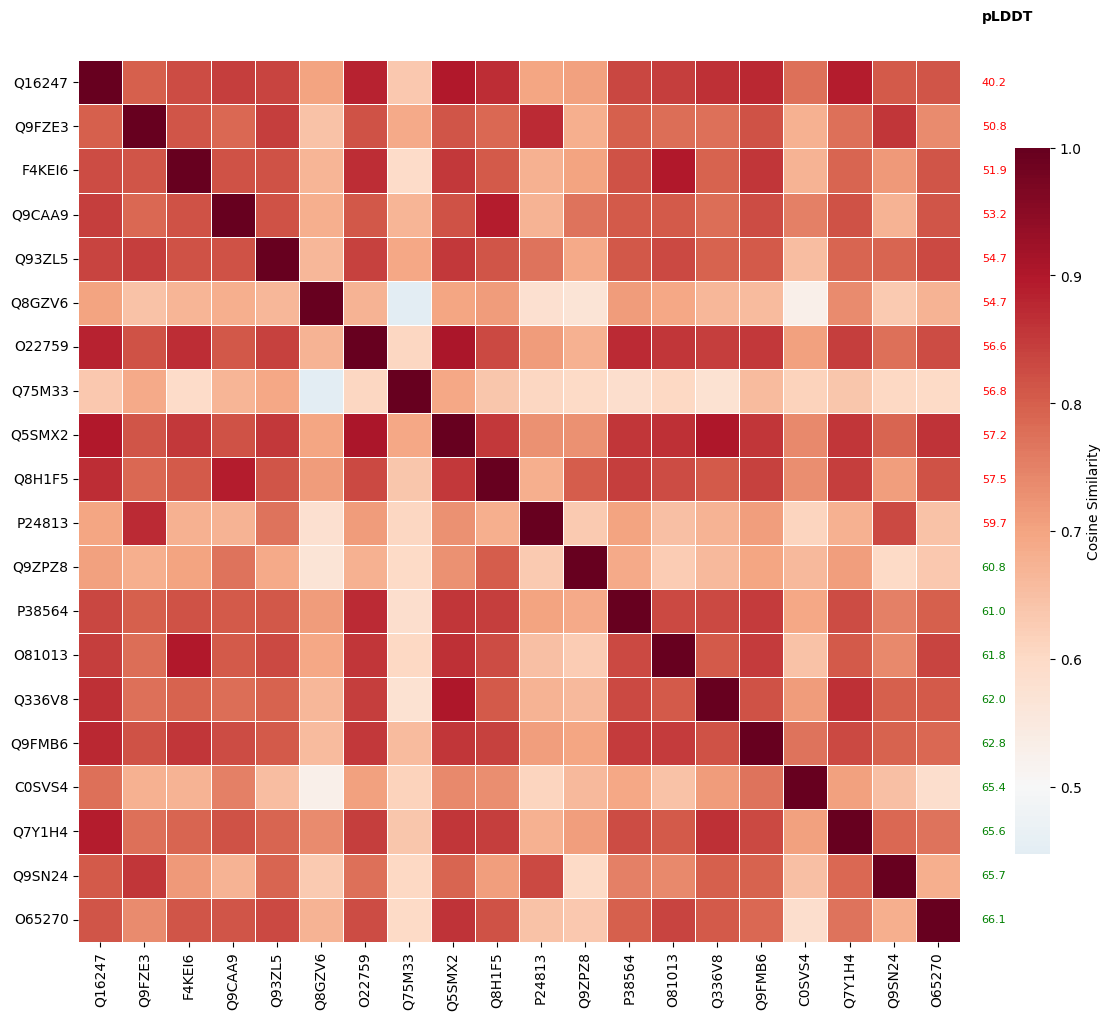

In [70]:
fig2 = create_feature_heatmap(protein_features, protein_list, group_proteins)

In [78]:
obo_path = prj_root / "data" / "data-netgo" / "go.obo"
godag = get_godag(obo_path, optional_attrs="relationship")

  EXISTS: /data0/shaojiangyi/pprogo-flg-1/data/data-netgo/go.obo
/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/go.obo: fmt(1.2) rel(2021-01-01) 47,285 Terms; optional_attrs(relationship)


In [79]:
# go_ids = ["GO:0006351", 
#           "GO:0006355",
#           ]
go_ids = list(inter_anno)
gosubdag = GoSubDag(go_ids, godag, relationships=False, prt=False)
saving_dir = prj_root / "notebooks" /"case_analysis" / "go_dag"
# saving_path = saving_dir / f"subdag_{'_'.join(go_ids[:5])}.svg"
# GoSubDagPlot(gosubdag).plt_dag(saving_path)
dag = GoSubDagPlot(gosubdag).get_pydot_graph()
saving_path = saving_dir / f"subdag_{'_'.join(go_ids[:5])}.dot"
dag.write_raw(saving_path)

In [80]:
def update_dot_colors(input_file, output_file, color_scheme='professional'):
    """
    Update DOT file with academic color schemes
    """
    color_schemes = {
        'professional': {
            'main_fill': '#e8f0fe',
            'main_border': '#1a73e8',
            'special_fill': '#f8f9fa', 
            'special_border': '#5f6368'
        },
        'grayscale': {
            'main_fill': '#f5f5f5',
            'main_border': '#424242',
            'special_fill': 'white',
            'special_border': '#757575'
        },
        'nature': {
            'main_fill': '#ecf0f1',
            'main_border': '#2c3e50',
            'special_fill': 'white',
            'special_border': '#7f8c8d'
        },
        'mine_1': {
            'main_fill': "#A6C2F2",
            'main_border': "#4472C4",
            'special_fill': 'white',
            'special_border': "#5c6d6e"
        }
    }
    
    scheme = color_schemes.get(color_scheme, color_schemes['professional'])
    
    with open(input_file, 'r') as f:
        content = f.read()
    
    # Replace colors
    content = content.replace('fillcolor="#ffffe4"', f'fillcolor="{scheme["main_fill"]}"')
    content = content.replace('fillcolor=white', f'fillcolor="{scheme["special_fill"]}"')
    content = content.replace('color=mediumseagreen', f'color="{scheme["main_border"]}"')
    
    # Update special node borders
    lines = content.split('\n')
    for i, line in enumerate(lines):
        if 'fillcolor="' + scheme["special_fill"] + '"' in line:
            lines[i] = line.replace(f'color="{scheme["main_border"]}"', f'color="{scheme["special_border"]}"')
    
    content = '\n'.join(lines)
    
    with open(output_file, 'w') as f:
        f.write(content)
    
    print(f"Updated DOT file saved as: {output_file}")

In [130]:
def parse_dot_file_structure(dot_content):
    """
    Parse existing DOT file structure without changing it
    """
    # Extract nodes with their current attributes
    node_pattern = r'"([^"]+)"\s*\[([^\]]+)\]'
    nodes = re.findall(node_pattern, dot_content)
    
    # Extract edges to understand hierarchy
    edge_pattern = r'"([^"]+)"\s*->\s*"([^"]+)"'
    edges = re.findall(edge_pattern, dot_content)
    
    return nodes, edges
def analyze_existing_hierarchy(nodes, edges):
    """
    Analyze the existing hierarchy from the DOT file structure
    """
    # Create graph to analyze hierarchy
    G = nx.DiGraph()
    
    # Add all nodes
    for node_name, attributes in nodes:
        G.add_node(node_name)
    
    # Add all edges
    for source, target in edges:
        if source in G.nodes() and target in G.nodes():
            G.add_edge(source, target)
    
    # Calculate hierarchy levels based on graph structure
    # Find root nodes (no incoming edges)
    root_nodes = [node for node in G.nodes() if G.in_degree(node) == 0]
    
    if not root_nodes:
        # If no clear roots, find nodes with minimum incoming edges
        min_in_degree = min(G.in_degree(node) for node in G.nodes())
        root_nodes = [node for node in G.nodes() if G.in_degree(node) == min_in_degree]
    
    # BFS to assign hierarchy levels
    levels = {}
    queue = clt.deque()
    
    # Start from root nodes at level 0
    for root in root_nodes:
        levels[root] = 0
        queue.append((root, 0))
    
    # BFS traversal to assign levels
    while queue:
        current_node, current_level = queue.popleft()
        
        for child in G.successors(current_node):
            child_level = current_level + 1
            if child not in levels or levels[child] < child_level:
                levels[child] = child_level
                queue.append((child, child_level))
    
    # Handle any disconnected nodes
    for node in G.nodes():
        if node not in levels:
            levels[node] = 0  # Assign to root level
    
    return levels
def is_white_node(attributes):
    """
    Check if node is originally white (unpredicted)
    """
    return ('fillcolor=white' in attributes or 
            'fillcolor="white"' in attributes or
            'fillcolor=White' in attributes or
            'fillcolor="White"' in attributes)
def get_hierarchy_colors(max_level):
    """
    Generate hierarchy colors
    """
    # Colors for different hierarchy levels (deeper = darker)
    # High levels are now dark, low levels are light
    border_colors = [
        '#bbdefb',  # Level 0: Lightest blue (root)
        '#90caf9',  # Level 1: Very light blue
        '#64b5f6',  # Level 2: Lighter blue
        '#42a5f5',  # Level 3: Light blue
        "#2d8fe6",  # Level 4: Medium-light blue
        "#2f86dd",  # Level 5: Medium blue
        "#1c70cf",  # Level 6: Medium-dark blue
        "#1362bd",  # Level 7+: Dark blue
    ]
    # High levels are now a light color, low levels are white
    fill_colors = [
        '#ffffff',  # Level 0: White (root)
        '#ffffff',  # Level 1: White
        '#fcfdff',  # Level 2: Nearly white
        '#fafcff',  # Level 3: Almost white blue
        '#f8fbff',  # Level 4: Very pale blue
        '#f0f8ff',  # Level 5: Alice blue
        '#e8f4f8',  # Level 6: Light blue-gray
        '#e3f2fd',  # Level 7+: Very light blue
    ]
    
    # Extend arrays if needed
    while len(border_colors) <= max_level:
        border_colors.append(border_colors[-1])
    while len(fill_colors) <= max_level:
        fill_colors.append(fill_colors[-1])
    
    return border_colors, fill_colors
def get_white_node_colors(treatment='keep_white'):
    """
    Get colors for originally white (unpredicted) nodes
    """
    treatments = {
        'keep_white': {
            'border': '#757575',  # Gray border
            'fill': 'white'       # Keep white
        },
        'red_contrast': {
            'border': '#d32f2f',  # Red border
            'fill': '#ffebee'     # Very light red
        },
        'orange_contrast': {
            'border': '#f57c00',  # Orange border  
            'fill': '#fff3e0'     # Very light orange
        },
        'dashed_gray': {
            'border': '#616161',  # Dark gray
            'fill': 'white',      # White fill
            'extra_attrs': 'style=dashed'  # Dashed style
        }
    }
    return treatments.get(treatment, treatments['keep_white'])
def update_node_colors_only(input_file, output_file=None, white_treatment='keep_white'):
    """
    Update only the colors of nodes based on existing hierarchy
    """
    if output_file is None:
        base_name = input_file.replace('.dot', '')
        output_file = f"{base_name}_hierarchy_colored.dot"
    
    # Read original DOT file
    with open(input_file, 'r', encoding='utf-8') as f:
        original_content = f.read()
    
    print(f"Analyzing hierarchy in: {input_file}")
    
    # Parse existing structure
    nodes, edges = parse_dot_file_structure(original_content)
    
    # Analyze existing hierarchy
    hierarchy_levels = analyze_existing_hierarchy(nodes, edges)
    
    # Identify white nodes and predicted nodes
    white_nodes = set()
    predicted_nodes = {}
    max_level = 0
    
    for node_name, attributes in nodes:
        if is_white_node(attributes):
            white_nodes.add(node_name)
        else:
            level = hierarchy_levels.get(node_name, 0)
            predicted_nodes[node_name] = level
            max_level = max(max_level, level)
    
    print(f"Found {len(predicted_nodes)} predicted nodes (levels 0-{max_level})")
    print(f"Found {len(white_nodes)} unpredicted nodes (white)")
    
    # Get color schemes
    border_colors, fill_colors = get_hierarchy_colors(max_level)
    white_colors = get_white_node_colors(white_treatment)
    
    # Update content by replacing node definitions
    updated_content = original_content
    
    for node_name, original_attributes in nodes:
        if node_name in white_nodes:
            # Handle white (unpredicted) nodes
            new_attributes = original_attributes
            
            # Update border color
            if 'color=' in new_attributes:
                new_attributes = re.sub(
                    r'color="?[^",\s\]]*"?', 
                    f'color="{white_colors["border"]}"', 
                    new_attributes
                )
            else:
                new_attributes = new_attributes.rstrip('] ') + f', color="{white_colors["border"]}"'
            
            # Keep or update fill color
            if white_colors['fill'] != 'white':
                new_attributes = re.sub(
                    r'fillcolor="?white"?', 
                    f'fillcolor="{white_colors["fill"]}"', 
                    new_attributes, 
                    flags=re.IGNORECASE
                )
            
            # Add extra attributes if needed (like dashed style)
            if 'extra_attrs' in white_colors:
                if not white_colors['extra_attrs'] in new_attributes:
                    new_attributes = new_attributes.rstrip('] ') + f', {white_colors["extra_attrs"]}'
                    
        else:
            # Handle predicted nodes with hierarchy colors
            level = predicted_nodes.get(node_name, 0)
            border_color = border_colors[level]
            fill_color = fill_colors[level]
            
            new_attributes = original_attributes
            
            # Update fill color
            if 'fillcolor=' in new_attributes:
                new_attributes = re.sub(
                    r'fillcolor="?[^",\s\]]*"?', 
                    f'fillcolor="{fill_color}"', 
                    new_attributes
                )
            else:
                new_attributes = new_attributes.rstrip('] ') + f', fillcolor="{fill_color}"'
            
            # Update border color
            if 'color=' in new_attributes:
                new_attributes = re.sub(
                    r'color="?[^",\s\]]*"?', 
                    f'color="{border_color}"', 
                    new_attributes
                )
            else:
                new_attributes = new_attributes.rstrip('] ') + f', color="{border_color}"'
        
        # Replace the node definition in content
        old_node = f'"{node_name}" [{original_attributes}]'
        new_node = f'"{node_name}" [{new_attributes}]'
        
        updated_content = updated_content.replace(old_node, new_node)
    
    # Write updated DOT file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(updated_content)
    
    # Print summary
    print(f"\n" + "="*50)
    print(f"COLOR UPDATE SUMMARY")
    print(f"="*50)
    
    if predicted_nodes:
        level_counts = clt.defaultdict(int)
        for level in predicted_nodes.values():
            level_counts[level] += 1
        
        print(f"PREDICTED NODES (Hierarchy Colored):")
        for level in sorted(level_counts.keys()):
            count = level_counts[level]
            print(f"  Level {level}: {count:2d} nodes - {border_colors[level]} / {fill_colors[level]}")
    
    if white_nodes:
        print(f"\nUNPREDICTED NODES ({white_treatment}):")
        print(f"  Count: {len(white_nodes)} nodes")
        print(f"  Colors: {white_colors['border']} / {white_colors['fill']}")
    
    print(f"\nOutput saved to: {output_file}")
    print(f"="*50)
    
    return output_file
def batch_color_variations(input_file):
    """
    Generate multiple color variations for comparison
    """
    base_name = input_file.replace('.dot', '')
    treatments = ['keep_white', 'red_contrast', 'orange_contrast', 'dashed_gray']
    
    outputs = []
    for treatment in treatments:
        output_file = f"{base_name}_{treatment}.dot"
        result = update_node_colors_only(input_file, output_file, treatment)
        outputs.append(result)
        print(f"Generated: {result}")
    
    return outputs

In [131]:
dot_dir = prj_root / "notebooks" / "case_analysis" / "go_dag"
dot_path = dot_dir / f"subdag_{'_'.join(go_ids[:5])}.dot"
# style = "nature"
# new_path = dot_dir / f"subdag_{style}_{'_'.join(go_ids[:5])}.dot"
new_path = dot_dir / f"hierarchy_{'_'.join(go_ids[:5])}.dot"
# Usage
# update_dot_colors(dot_path, new_path, style)
# update_dot_hierarchy_colors_with_white_handling(dot_path, new_path)
update_node_colors_only(dot_path, new_path)

Analyzing hierarchy in: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/subdag_GO:0044237_GO:0008152_GO:0051252_GO:0050789_GO:0009987.dot
Found 48 predicted nodes (levels 0-9)
Found 3 unpredicted nodes (white)

COLOR UPDATE SUMMARY
PREDICTED NODES (Hierarchy Colored):
  Level 0:  1 nodes - #bbdefb / #ffffff
  Level 1:  3 nodes - #90caf9 / #ffffff
  Level 2:  6 nodes - #64b5f6 / #fcfdff
  Level 3:  9 nodes - #42a5f5 / #fafcff
  Level 4: 13 nodes - #2d8fe6 / #f8fbff
  Level 5:  7 nodes - #2f86dd / #f0f8ff
  Level 6:  3 nodes - #1c70cf / #e8f4f8
  Level 7:  2 nodes - #1362bd / #e3f2fd
  Level 8:  2 nodes - #1362bd / #e3f2fd
  Level 9:  2 nodes - #1362bd / #e3f2fd

UNPREDICTED NODES (keep_white):
  Count: 3 nodes
  Colors: #757575 / white

Output saved to: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/hierarchy_GO:0044237_GO:0008152_GO:0051252_GO:0050789_GO:0009987.dot


PosixPath('/data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/hierarchy_GO:0044237_GO:0008152_GO:0051252_GO:0050789_GO:0009987.dot')

In [ ]:
def verify_svg_content(svg_path):
    """
    Verify SVG file has actual content (not just white/empty)
    """
    try:
        if os.path.exists(svg_path):
            with open(svg_path, 'r', encoding='utf-8') as f:
                svg_content = f.read()
            
            # Check for actual graphical content
            if 'polygon' in svg_content or 'rect' in svg_content or 'ellipse' in svg_content:
                print("✓ SVG contains graphical elements")
                
                # Check file size
                file_size = os.path.getsize(svg_path)
                print(f"✓ SVG file size: {file_size} bytes")
                
                # Check for color information
                if 'fill=' in svg_content and 'stroke=' in svg_content:
                    print("✓ SVG contains color information")
                else:
                    print("⚠ SVG might be missing color information")
            else:
                print("⚠ SVG appears to be empty or malformed")
                print("First 500 chars of SVG:")
                print(svg_content[:500])
    except Exception as e:
        print(f"Error verifying SVG: {e}")
        
def plot_dot_file(dot_file_path, output_dir='./output', base_name='graph'):
    """
    Plot DOT file with error handling and custom settings
    """
    try:
        # Check if DOT file exists
        if not os.path.exists(dot_file_path):
            raise FileNotFoundError(f"DOT file not found: {dot_file_path}")
        
        # Create output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Read DOT file content
        with open(dot_file_path, 'r', encoding='utf-8') as f:
            dot_content = f.read()
        
        # Clean base_name to avoid filesystem issues
        clean_base_name = base_name.replace(':', '_').replace('/', '_').replace('\\', '_')
        
        # Create separate graph objects for each format
        png_graph = graphviz.Source(dot_content)
        svg_graph = graphviz.Source(dot_content)
        
        # Set format-specific attributes
        png_graph.format = 'png'
        svg_graph.format = 'svg'

        # Different output paths to avoid conflicts
        png_path = os.path.join(output_dir, f"{clean_base_name}_png")
        svg_path = os.path.join(output_dir, f"{clean_base_name}_svg")
        
        # Render PNG
        png_result = png_graph.render(png_path, cleanup=True)
        print(f"PNG rendered to: {png_result}")
        
        # Render SVG
        svg_result = svg_graph.render(svg_path, cleanup=True)
        print(f"SVG rendered to: {svg_result}")
        
        # Rename files to have consistent naming
        final_png = os.path.join(output_dir, f"{clean_base_name}.png")
        final_svg = os.path.join(output_dir, f"{clean_base_name}.svg")
        
        if os.path.exists(png_result):
            os.rename(png_result, final_png)
        if os.path.exists(svg_result):
            os.rename(svg_result, final_svg)
        
        print(f"Successfully rendered:")
        print(f"  PNG: {final_png}")
        print(f"  SVG: {final_svg}")
        
        # Verify SVG content
        verify_svg_content(final_svg)
        
        return True
        
    except Exception as e:
        print(f"Error rendering DOT file: {e}")
        return False


In [132]:
go_ids = list(inter_anno)
# dot_path = prj_root / "notebooks" / "case_analysis" / "edge" / "genescape.dot"
dot_dir = prj_root / "notebooks" / "case_analysis" / "go_dag"
# style = "professional"
# dot_path = dot_dir / f"subdag_{style}_{'_'.join(go_ids[:5])}.dot"
dot_path = dot_dir / f"hierarchy_{'_'.join(go_ids[:5])}.dot"
save_path = dot_path.parent
plot_dot_file(str(dot_path), str(save_path), 
            #   f"graphviz_{'_'.join(go_ids[:5])}"
            f"gviz_hier_{'_'.join(go_ids[:5])}"
              )
# plot_dot_file_with_dpi_optimization(str(dot_path), str(save_path), 
#             #   f"graphviz_{'_'.join(go_ids[:5])}"
#             f"gviz_hier_{'_'.join(go_ids[:5])}",
#             min_dpi=18
#               )

PNG rendered to: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/gviz_hier_GO_0044237_GO_0008152_GO_0051252_GO_0050789_GO_0009987_png.png
SVG rendered to: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/gviz_hier_GO_0044237_GO_0008152_GO_0051252_GO_0050789_GO_0009987_svg.svg
Successfully rendered:
  PNG: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/gviz_hier_GO_0044237_GO_0008152_GO_0051252_GO_0050789_GO_0009987.png
  SVG: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/gviz_hier_GO_0044237_GO_0008152_GO_0051252_GO_0050789_GO_0009987.svg
✓ SVG contains graphical elements
✓ SVG file size: 80571 bytes
✓ SVG contains color information


True

In [131]:
def debug_and_plot(dot_file_path, output_dir='./output', base_name='graph'):
    """
    Enhanced version with comprehensive debugging
    """
    try:
        if not os.path.exists(dot_file_path):
            raise FileNotFoundError(f"DOT file not found: {dot_file_path}")
        
        os.makedirs(output_dir, exist_ok=True)
        
        with open(dot_file_path, 'r', encoding='utf-8') as f:
            dot_content = f.read()
        
        print("Debugging DOT content...")
        print(f"Content length: {len(dot_content)} characters")
        
        # Check for problematic characters or formatting
        if '\r\n' in dot_content:
            print("Converting Windows line endings...")
            dot_content = dot_content.replace('\r\n', '\n')
        
        clean_base_name = base_name.replace(':', '_').replace('/', '_').replace('\\', '_')
        
        # Test with a simple graph first
        test_graph = graphviz.Source('digraph { A -> B; }')
        test_graph.format = 'svg'
        test_path = os.path.join(output_dir, 'test')
        test_graph.render(test_path, cleanup=True)
        
        if os.path.exists(f"{test_path}.svg"):
            print("✓ Basic SVG rendering works")
            os.remove(f"{test_path}.svg")
        else:
            print("✗ Basic SVG rendering failed - Graphviz issue")
            return False
        
        # Now render the actual graph
        formats = ['png', 'svg']
        results = {}
        
        for fmt in formats:
            try:
                graph = graphviz.Source(dot_content)
                graph.format = fmt
                output_path = os.path.join(output_dir, f"{clean_base_name}_{fmt}")
                
                result = graph.render(output_path, cleanup=True)
                results[fmt] = result
                
                # Check file size and content
                if os.path.exists(result):
                    size = os.path.getsize(result)
                    print(f"✓ {fmt.upper()} rendered: {result} ({size} bytes)")
                    
                    if fmt == 'svg' and size < 1000:  # SVG too small might be empty
                        print("⚠ SVG file suspiciously small, checking content...")
                        with open(result, 'r') as f:
                            svg_sample = f.read(500)
                            print(f"SVG sample: {svg_sample}")
                else:
                    print(f"✗ {fmt.upper()} file not found: {result}")
                    
            except Exception as e:
                print(f"✗ Error rendering {fmt.upper()}: {e}")
        
        return len(results) == 2
        
    except Exception as e:
        print(f"Error in debug_and_plot: {e}")
        return False

In [132]:
go_ids = list(inter_anno)
# dot_path = prj_root / "notebooks" / "case_analysis" / "edge" / "genescape.dot"
dot_dir = prj_root / "notebooks" / "case_analysis" / "go_dag"
# style = "professional"
dot_path = dot_dir / f"subdag_{style}_{'_'.join(go_ids[:5])}.dot"
save_path = dot_path.parent
debug_and_plot(str(dot_path), str(save_path), f"graphviz_{'_'.join(go_ids[:5])}")

Debugging DOT content...
Content length: 21089 characters
✓ Basic SVG rendering works
✓ PNG rendered: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/graphviz_GO_0010467_GO_0051171_GO_0006139_GO_0009889_GO_0009987_png.png (1341079 bytes)
✓ SVG rendered: /data0/shaojiangyi/pprogo-flg-1/notebooks/case_analysis/go_dag/graphviz_GO_0010467_GO_0051171_GO_0006139_GO_0009889_GO_0009987_svg.svg (79858 bytes)


True